# NYC Property Sales: Exploratory Data Analysis

## Objective

Explore how residential sale prices vary across New York City's five boroughs and property categories, examine the relationship between property size and sale price, compare price per square foot where building-area data is available, and assess observed differences between 2024 and 2025.

In [21]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

pd.set_option("display.max_columns", None)

# Define the path to the cleaned and integrated dataset created in
# Notebook 2.
DATA_PATH = Path("../data/processed/nyc_property_sales_2024_2025.csv")

# Load the processed property-sales and parse sale dates as datetimes.
property_sales = pd.read_csv(
    DATA_PATH,
    parse_dates=["sale_date"],
    low_memory=False,
)

# Confirm that the expected number of rows and columns was loaded.
property_sales.shape

(163311, 29)

In [2]:
property_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 163311 entries, 0 to 163310
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   borough                         163311 non-null  str           
 1   neighborhood                    163311 non-null  str           
 2   building_class_category         163311 non-null  str           
 3   tax_class_at_present            163311 non-null  str           
 4   block                           163311 non-null  int64         
 5   lot                             163311 non-null  int64         
 6   building_class_at_present       163311 non-null  str           
 7   address                         163311 non-null  str           
 8   apartment_number                39372 non-null   str           
 9   zip_code                        163288 non-null  float64       
 10  residential_units               123732 non-null  float64       
 11

## Analytical Populations

The analysis uses two subsets of the integrated dataset. Residential positive-price sales are used for analyses of recorded sale prices, transaction activity, and property categories. A narrower size-eligible subset is used when gross building area is required.

A positive recorded sale price does not necessarily represent a verified arm's-length market transaction. Results are therefore interpreted as patterns in recorded residential positive-price sales rather than confirmed market-value transactions.

In [6]:
# Create the subset used for residential sale-price analyses.
residential_sales = property_sales.loc[
    property_sales["is_residential_market_sale"]
].copy()

# Create the narrowwer subset used for analyses that require
# gross building area.
size_sales = property_sales.loc[
    property_sales["is_size_analysis_eligible"]
].copy()

# Summarize the number of records available at each
# analytical stage.
analysis_counts = pd.Series(
    {
        "Integrated records": len(property_sales),
        "Residential records": property_sales["is_residential"].sum(),
        "Residential positive-price sales": len(residential_sales),
        "Size-analysis eligible sales": len(size_sales),
    }
)

analysis_counts

Integrated records                  163311
Residential records                 149087
Residential positive-price sales     97849
Size-analysis eligible sales         45111
dtype: int64

## Residential Sale-Price Distribution

Residential positive-price sales are compared across the five boroughs to examine differences in transaction activity, typical sale prices, and the shape of recorded sale-price distributions.

In [12]:
# Count residential positive-price sales in each borough.
borough_sales_counts = (
    residential_sales["borough"]
    .value_counts()
    .rename("sales")
)

borough_sales_counts

borough
Queens           29755
Manhattan        26575
Brooklyn         24739
Staten Island     9009
Bronx             7771
Name: sales, dtype: int64

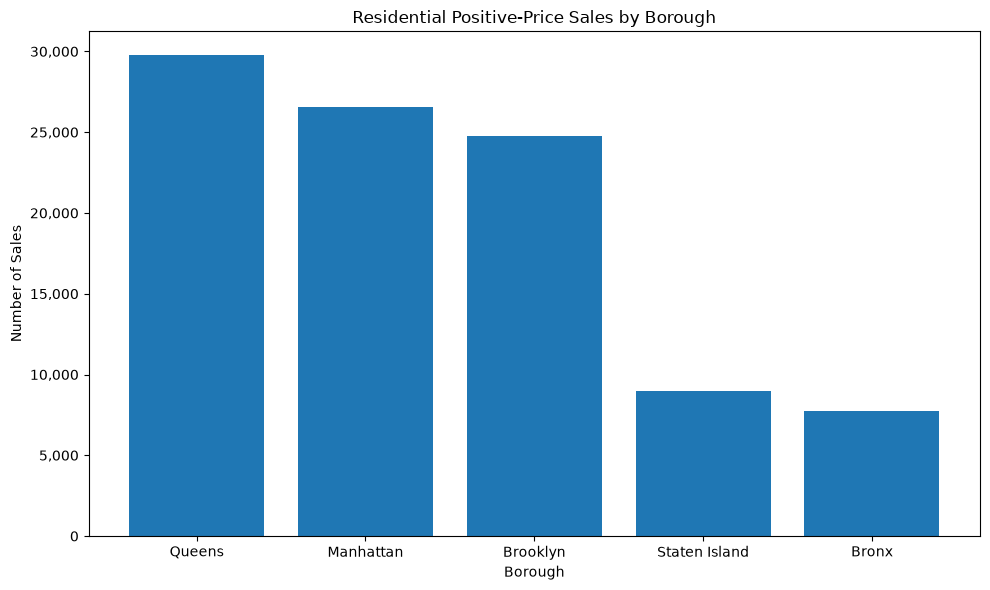

In [18]:
# Create a figure and axes using Matplotlib's object-oriented interface.
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the verified residential positive-price sale counts by borough.
ax.bar(
    borough_sales_counts.index,
    borough_sales_counts.values,
)

# Add descriptive labels and a title.
ax.set_title("Residential Positive-Price Sales by Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of Sales")

# Format the y-axis with comma-separated counts.
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value:,.0f}")
)

# Improve spacing without relying on Matplotlib's stateful layout
# interface.
fig.tight_layout()
plt.show()

In [15]:
# Summarize the distribution of residential sale prices
# within each borough.
borough_price_summary = (
    residential_sales
    .groupby("borough")["sale_price"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

# Arrange boroughs from highest to lowest median sale price.
borough_price_summary = borough_price_summary.sort_values(
    "50%",
    ascending=False,
)

# Display the summary in currency-friendly numeric format.
borough_price_summary.round(2)

,count,mean,std,min,25%,50%,75%,90%,95%,max
borough,,,,,,,,,,
Manhattan,26575.0,2668782.57,8120618.49,1.0,661863.0,1200000.0,2425000.0,4999000.0,8000000.0,810000000.0
Brooklyn,24739.0,1439645.12,2856393.48,1.0,600000.0,985000.0,1641625.0,2628400.0,3605100.0,202500000.0
Queens,29755.0,934321.83,1910746.82,1.0,388181.0,690000.0,988000.0,1375000.0,1690000.0,83558226.0
Staten Island,9009.0,745996.36,2264767.51,1.0,506000.0,680000.0,850238.0,1100000.0,1303360.0,135259627.0
Bronx,7771.0,1290391.16,5071427.74,1.0,280000.0,625000.0,900000.0,1325000.0,3621585.0,84680401.0


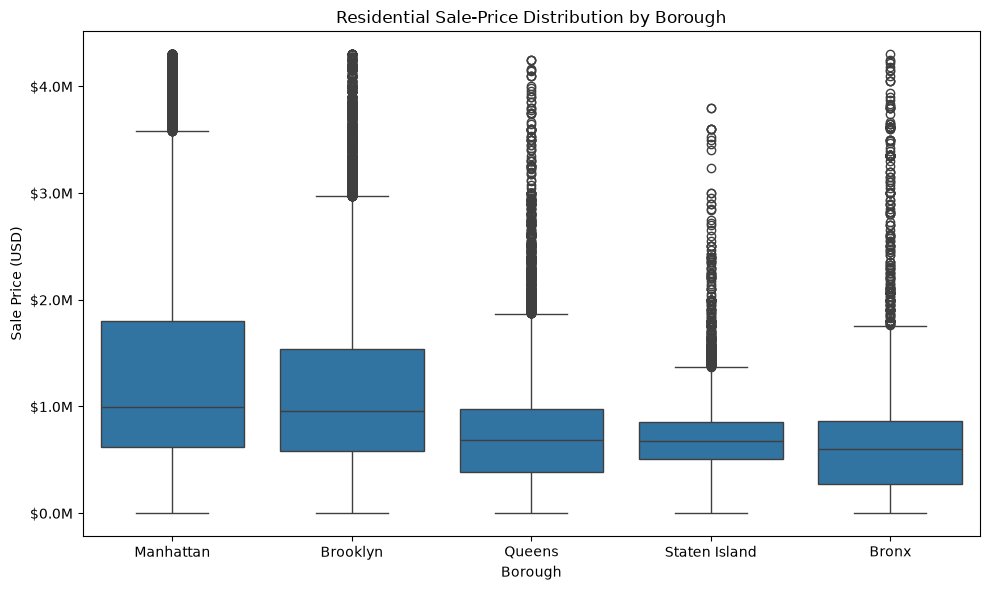

In [19]:
# Limit the displayed range to improve comparability across boroughs.
sale_price_95th = residential_sales["sale_price"].quantile(0.95)
sale_price_display = residential_sales.loc[
    residential_sales["sale_price"] <= sale_price_95th
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=sale_price_display,
    x="borough",
    y="sale_price",
    order=borough_price_summary.index,
    ax=ax,
)

ax.set_title("Residential Sale-Price Distribution by Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Sale Price (USD)")
# Format the sale-price axis as USD.
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"${value / 1_000_000:.1f}M"
    )
)

fig.tight_layout()
plt.show()

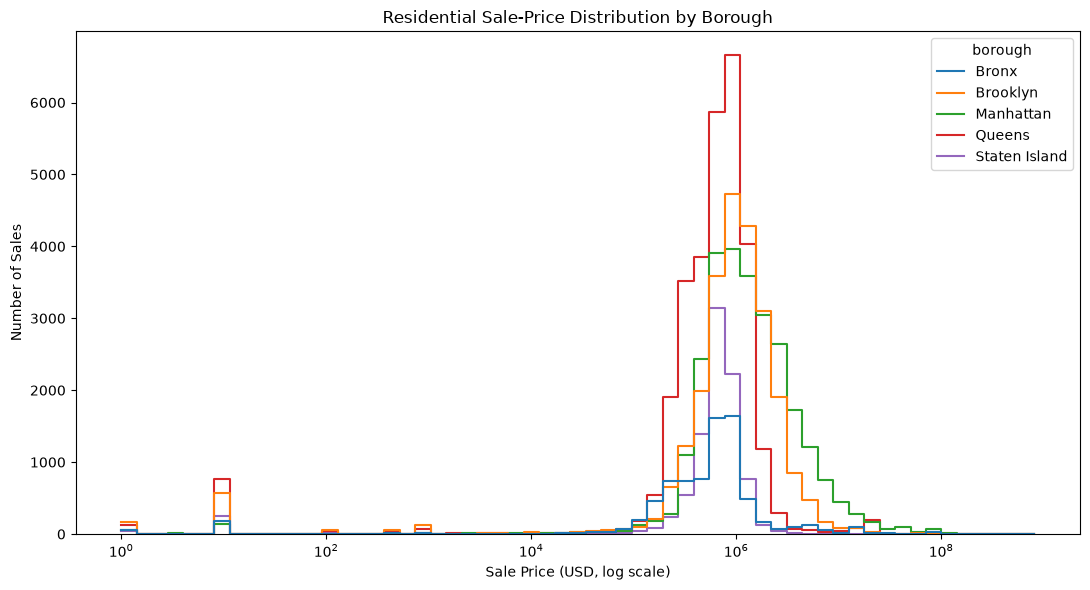

In [22]:
# Use logarithmically spaced bins to show the full sale-price range.
log_bins = np.logspace(
    np.log10(residential_sales["sale_price"].min()),
    np.log10(residential_sales["sale_price"].max()),
    60,
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=residential_sales,
    x="sale_price",
    hue="borough",
    bins=log_bins,
    element="step",
    fill=False,
    common_norm=False,
    ax=ax,
)

ax.set_xscale("log")
ax.set_title("Residential Sale-Price Distribution by Borough")
ax.set_xlabel("Sale Price (USD, log scale)")
ax.set_ylabel("Number of Sales")

fig.tight_layout()
plt.show()

### Findings

> **How do residential sale-price distributions differ across the five boroughs?**

Residential sale prices differ substantially across NYC's five boroughs. Manhattan recorded the highest median sale price at `$1.20 million`, followed by Brooklyn at `$985,000`. Queens and Staten Island had similar medians of `$690,000` and `$680,000`, respectively, while the Bronx had the lowest median at `$625,000`.

Sale-price distributions are strongly right-skewed across all boroughs, with mean prices exceeding medians and a relatively small number of high-value transactions extending the upper tails. Manhattan shows the strongest concentration of high-price transactions.

Transaction volume follows a different pattern from price levels. Queens recorded the most residential positive-price sales, while Manhattan had the highest median price. This indicates that borough-level transaction activity and typical transaction value capture different aspects of the observed market.

The data also contains nominal positive sale prices, including transactions recorded for only a few dollars. Because a positive recorded price does not establish an arm's-length market transaction, the results describe recorded residential positive-price sales rather than verified market values.

## Residential Sales by Year

Residential positive-price sales are compared between 2024 and 2025 to examine observed differences in transaction activity and sale prices. These comparisons are descriptive and may reflect differences in the composition of properties sold between the two years.

In [23]:
# Summarize transaction activity and sale-price distributions
# by source year
year_summary = (
    residential_sales
    .groupby("source_year")["sale_price"]
    .agg(
        sales="size",
        median="median",
        mean="mean",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
)

year_summary.round(2)

,sales,median,mean,q1,q3
source_year,,,,,
2024,47443,799000.0,1439325.24,495000.0,1300000.0
2025,50406,840500.0,1642689.90,515000.0,1400000.0


In [24]:
# Quantify the observed year-over-year changes in transaction count
# and median sale price.
year_change = pd.Series(
    {
        "Sales count change (%)": (
            year_summary.loc[2025, "sales"]
            / year_summary.loc[2024, "sales"]
            - 1
        ) * 100,
        "Median sale price change (%)": (
            year_summary.loc[2025, "median"]
            / year_summary.loc[2024, "median"]
            - 1
        ) * 100,
    }
)

year_change.round(2)

Sales count change (%)          6.25
Median sale price change (%)    5.19
dtype: float64

In [25]:
# Compare transaction counts and median sale prices by borough and year.
borough_year_summary = (
    residential_sales
    .groupby(["borough", "source_year"])
    .agg(
        sales=("sale_price", "size"),
        median_sale_price=("sale_price", "median"),
    )
    .reset_index()
)

borough_year_summary

,borough,source_year,sales,median_sale_price
0,Bronx,2024,3793,610000.0
1,Bronx,2025,3978,639500.0
2,Brooklyn,2024,12033,955000.0
3,Brooklyn,2025,12706,998000.0
4,Manhattan,2024,12612,1185000.0
5,Manhattan,2025,13963,1200000.0
6,Queens,2024,14555,674082.0
7,Queens,2025,15200,705000.0
8,Staten Island,2024,4450,660000.0
9,Staten Island,2025,4559,700000.0


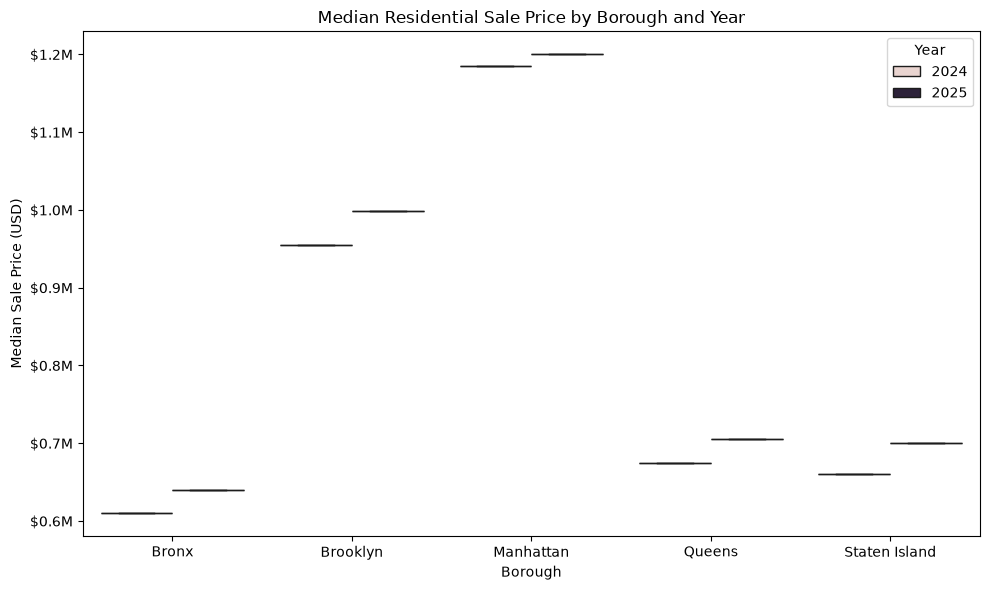

In [26]:
# Compare median recorded sale prices across boroughs and years.
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=borough_year_summary,
    x="borough",
    y="median_sale_price",
    hue="source_year",
    ax=ax,
)

ax.set_title("Median Residential Sale Price by Borough and Year")
ax.set_xlabel("Borough")
ax.set_ylabel("Median Sale Price (USD)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"${value / 1_000_000:.1f}M"
    )
)
ax.legend(title="Year")

fig.tight_layout()
plt.show()

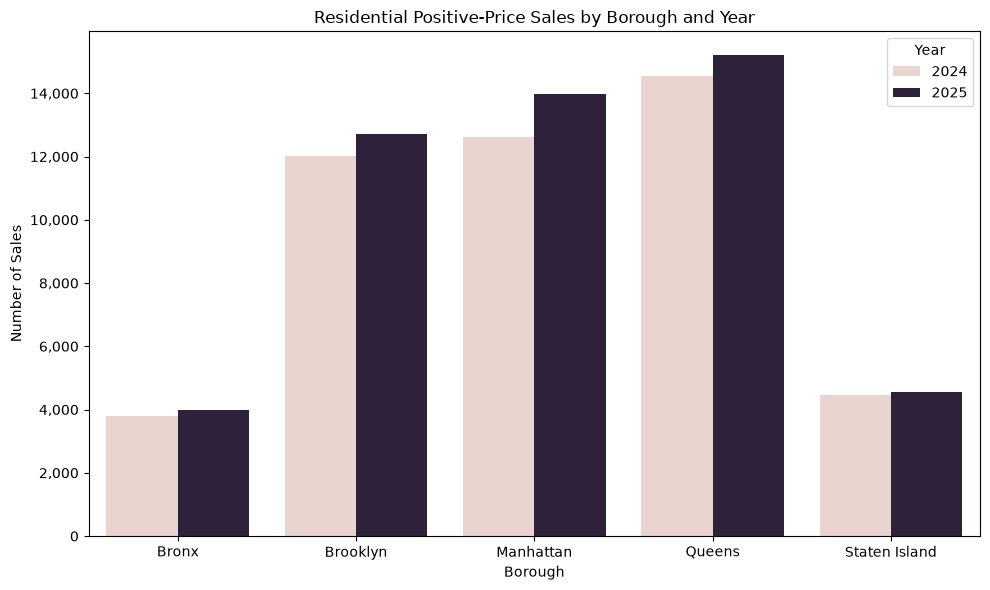

In [29]:
# Compare residential positive-price transaction counts across
# boroughs and years.
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=borough_year_summary,
    x="borough",
    y="sales",
    hue="source_year",
    ax=ax,
)

ax.set_title("Residential Positive-Price Sales by Borough and Year")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of Sales")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)
ax.legend(title="Year")

fig.tight_layout()
plt.show()

### Findings

> **How did observed residential property sales differ between 2024 and 2025?**

The dataset contains 50,406 residential positive-price sales in 2025 compared with 47,443 in 2024, an observed increase of 6.25%. The median recorded sale price also increased from `$799,000` to `$840,500`, a difference of 5.19%.

All five boroughs recorded higher transaction counts and higher median sale prices in 2025. Median prices increased from `$610,000` to `$639,500` in the Bronx, `$955,00` to `$998,000` in Brooklyn, `$1.185 million` to `$1.20 million` in Manhattan, `$674,082` to `$705,000` in Queens, and `$660,000` to `$700,000` in Staten Island.

These differences are descriptive rather than measures of property appreciation. The mix of properties sold may differ between years, so changes in the observed medians cannot be attributed solely to changes in the underlying property values.

## Residential Property Categories

Residential sale prices are compared across building categories to examine how transaction values vary among different types of residential property.

In [31]:
# Summarize transaction volume and sale-price distributions by
# residential property category
category_summary = (
    residential_sales
    .groupby("building_class_category")["sale_price"]
    .agg(
        sales="size",
        median="median",
        mean="mean",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .sort_values("median", ascending=False)
)

category_summary.round(2)

,sales,median,mean,q1,q3
building_class_category,,,,,
08 RENTALS - ELEVATOR APARTMENTS,645,4300000.0,13965980.08,1311812.00,11500000.0
14 RENTALS - 4-10 UNIT,693,1900000.0,3401247.53,1200000.00,3255000.0
07 RENTALS - WALKUP APARTMENTS,3165,1500000.0,3574735.15,900000.00,3325000.0
03 THREE FAMILY DWELLINGS,4102,1195155.5,1383917.75,855000.25,1650000.0
15 CONDOS - 2-10 UNIT RESIDENTIAL,2232,1132500.0,1741846.06,725000.00,1950000.0
13 CONDOS - ELEVATOR APARTMENTS,19310,1125000.0,2437817.18,662625.00,2189178.5
02 TWO FAMILY DWELLINGS,15579,950000.0,1113043.85,710000.00,1283708.0
17 CONDO COOPS,2032,799000.0,1672311.37,512250.00,1400000.0
01 ONE FAMILY DWELLINGS,21186,749000.0,947696.92,580000.00,975000.0


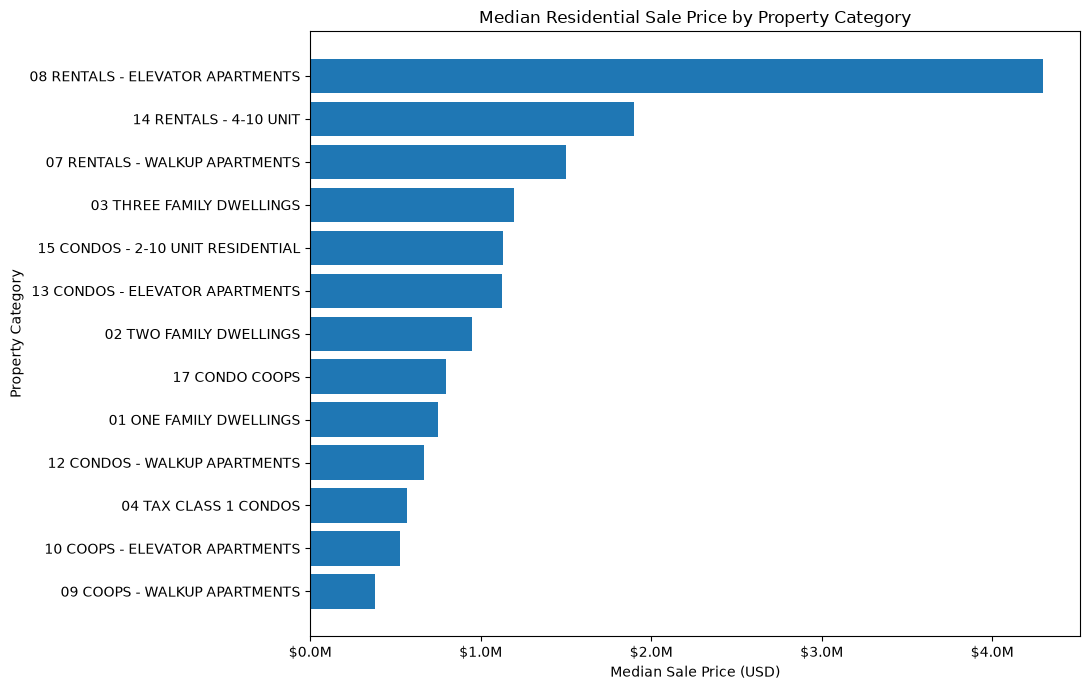

In [33]:
# Compare typical recorded sale prices across residential
# property categories.
fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    category_summary.index,
    category_summary["median"],
)

ax.set_title("Median Residential Sale Price by Property Category")
ax.set_xlabel("Median Sale Price (USD)")
ax.set_ylabel("Property Category")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"${value / 1_000_000:.1f}M"
    )
)

# Place the highest-median category at the top.
ax.invert_yaxis()

fig.tight_layout()
plt.show()

### Findings

> ***How do sale prices differ across residential property categories?***

Recorded sale prices vary substantially across residential property categories. Elevator rental buildings had the highest median transaction price at `$4.3 million`, followed by 4-10 unit rentals at `$1.9 million` and walk-up rental buildings at `$1.9 million` and walk-up rental buildings at `$1.5 million`.

Among one-, two-, and three-family dwellings, median sale prices increased with property type: `$749,000` for one-family, `$950,000` for two-family, and approximately `$1.20 million` for three-family dwellings. Condo categories also generally recorded higher medians than co-op categories.

These comparisons partly reflect differences in what is being sold. Rental categories can represent entire multi-unit buildings, while condo and co-op transactions commonly represent individual units. Property category is therefore associated with recorded transaction value, but the differences should not be interpreted as price effects caused by building type alone.

## Property Size and Sale Price

The relationship between gross building area and recorded sale price is evaluated using the size-eligible subset.

Gross square footage is available primarily for houses and rental buildings and is largely available for condo and co-op transactions. Size-based results therefore describe properties with reported building area rather than the full residential sales population.

In [35]:
# Summarize the variables used in the size-price analysis.
size_summary = size_sales[
    ["gross_square_feet", "sale_price"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

size_summary.round(2)

,gross_square_feet,sale_price
count,45111.00,4.511100e+04
mean,4527.48,1.451077e+06
std,25173.69,5.618509e+06
min,1.00,1.000000e+00
25%,1392.00,6.420000e+05
50%,1920.00,8.750000e+05
75%,2700.00,1.275000e+06
90%,3840.00,2.050000e+06
95%,5760.00,3.350000e+06
99%,50000.00,1.139500e+07


In [36]:
# Inspect unusually small building-area values before defining
# the final size-analysis population.
small_area_sales = size_sales.loc[
    size_sales["gross_square_feet"] < 500,
    [
        "source_year",
        "borough",
        "neighborhood",
        "building_class_category",
        "address",
        "gross_square_feet",
        "sale_price",
        "price_per_sqft",
    ],
].sort_values("gross_square_feet")

small_area_sales

,source_year,borough,neighborhood,building_class_category,address,gross_square_feet,sale_price,price_per_sqft
46868,2024,Queens,BAYSIDE,01 ONE FAMILY DWELLINGS,202-22 45TH DRIVE,1.0,1100000.0,1.100000e+06
156601,2025,Staten Island,CLOVE LAKES,01 ONE FAMILY DWELLINGS,274 MORRISON AVENUE,136.0,725000.0,5.330882e+03
157350,2025,Staten Island,GRANT CITY,01 ONE FAMILY DWELLINGS,20 LIBERTY AVENUE,220.0,860000.0,3.909091e+03
70704,2024,Staten Island,ANNADALE,01 ONE FAMILY DWELLINGS,26 ZEPHYR AVENUE,220.0,235000.0,1.068182e+03
141671,2025,Queens,HAMMELS,01 ONE FAMILY DWELLINGS,345 E BEACH 87 STREET,300.0,350000.0,1.166667e+03
79180,2025,Bronx,BRONXDALE,01 ONE FAMILY DWELLINGS,2912 LACONIA AVENUE,323.0,10.0,3.095975e-02
74152,2024,Staten Island,MIDLAND BEACH,02 TWO FAMILY DWELLINGS,299 COLONY AVENUE,340.0,282000.0,8.294118e+02
157903,2025,Staten Island,GREAT KILLS,01 ONE FAMILY DWELLINGS,197 WIMAN AVENUE,352.0,425000.0,1.207386e+03
46118,2024,Queens,ASTORIA,02 TWO FAMILY DWELLINGS,22-36 21ST STREET,357.0,310000.0,8.683473e+02
161658,2025,Staten Island,SOUTH BEACH,01 ONE FAMILY DWELLINGS,90 HICKORY AVENUE,385.0,525000.0,1.363636e+03


In [37]:
# Quantify the lower tail of reported gross building area.
small_area_counts = pd.Series(
    {
        "Below 10 sq ft": (size_sales["gross_square_feet"] < 10).sum(),
        "Below 50 sq ft": (size_sales["gross_square_feet"] < 50).sum(),
        "Below 100 sq ft": (size_sales["gross_square_feet"] < 100).sum(),
        "Below 250 sq ft": (size_sales["gross_square_feet"] < 250).sum(),
        "Below 500 sq ft": (size_sales["gross_square_feet"] < 500).sum(),
    }
)

small_area_counts

Below 10 sq ft      1
Below 50 sq ft      1
Below 100 sq ft     1
Below 250 sq ft     4
Below 500 sq ft    44
dtype: int64

In [38]:
# Exclude the isolated 1 sq ft record from anayses that
# depend on reported building area
size_analysis_sales = size_sales.loc[
    size_sales["gross_square_feet"] >= 100
].copy()

pd.Series(
    {
        "Original size-eligible sales": len(size_sales),
        "Final size-analysis sales": len(size_analysis_sales),
        "Excluded records": len(size_sales) - len(size_analysis_sales),
    }
)

Original size-eligible sales    45111
Final size-analysis sales       45110
Excluded records                    1
dtype: int64

In [39]:
# Inspeact the largest reported areas for potential
# data-quality issues.
size_analysis_sales.nlargest(
    20,
    "gross_square_feet",
)[
    [
        "source_year",
        "borough",
        "neighborhood",
        "building_class_category",
        "address",
        "gross_square_feet",
        "sale_price",
        "price_per_sqft",
    ]
]

,source_year,borough,neighborhood,building_class_category,address,gross_square_feet,sale_price,price_per_sqft
16667,2024,Brooklyn,EAST NEW YORK,08 RENTALS - ELEVATOR APARTMENTS,"735 LINCOLN AVENUE, 1276",1396750.0,87737978.0,62.815807
135085,2025,Queens,FAR ROCKAWAY,08 RENTALS - ELEVATOR APARTMENTS,125 BEACH 17TH ST,748461.0,83558226.0,111.640053
120546,2025,Manhattan,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,"420 EAST 63 ST, E3A",723578.0,732500.0,1.012330
120547,2025,Manhattan,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,"420 EAST 63RD ST, E11D",723578.0,1052174.0,1.454127
120548,2025,Manhattan,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,"425 EAST 63RD ST, W7B",723578.0,629291.0,0.869693
136655,2025,Queens,FLUSHING-NORTH,08 RENTALS - ELEVATOR APARTMENTS,131-02 40 ROAD,552699.0,32000000.0,57.897698
156779,2025,Staten Island,CONCORD-FOX HILLS,08 RENTALS - ELEVATOR APARTMENTS,200-280 PARK HILL AVENUE,408800.0,135259627.0,330.869929
156781,2025,Staten Island,CONCORD-FOX HILLS,08 RENTALS - ELEVATOR APARTMENTS,140 PARK HILL AVENUE,408800.0,135190739.0,330.701416
109889,2025,Manhattan,CLINTON,08 RENTALS - ELEVATOR APARTMENTS,560 WEST 43RD STREET,388073.0,243500000.0,627.459267
16666,2024,Brooklyn,EAST NEW YORK,08 RENTALS - ELEVATOR APARTMENTS,671 LINCOLN AVENUE,361644.0,87737978.0,242.608693


In [41]:
# Identify repeated address-area combinations that may represent
# building-level area reused across transactions.
repeated_area_records = (
    size_analysis_sales
    .groupby(
        ["borough", "address", "gross_square_feet"],
        dropna=False,
    )
    .size()
    .reset_index(name="transactions")
    .query("transactions > 1")
    .sort_values("transactions", ascending=False)
)

repeated_area_records.head(20)

,borough,address,gross_square_feet,transactions
4049,Bronx,630 EAST 234 STREET,1950.0,9
22147,Queens,121-41 133RD STREET,1120.0,6
35935,Queens,N/A HILLMEYER AVENUE,2142.0,6
43414,Staten Island,N/A HARRIS LANE,1790.0,5
21208,Queens,114-64 204TH STREET,1683.0,4
16148,Brooklyn,725 EUCLID AVENUE,1296.0,4
26197,Queens,188-26 DORMANS ROAD,1852.0,4
27469,Queens,223-30 HEMPSTEAD AVENUE,1935.0,4
35932,Queens,N/A BEACH 25 STREET,1972.0,4
39273,Staten Island,28 CLINTON PLACE,1992.0,4


In [43]:
# Examine the composition of the final size-analysis population by
# property category.
size_category_summary = (
    size_analysis_sales
    .groupby("building_class_category")
    .agg(
        sales=("sale_price", "size"),
        median_gross_sqft=("gross_square_feet", "median"),
        max_gross_sqft=("gross_square_feet", "max"),
        median_sale_price=("sale_price", "median"),
        median_price_per_sqft=("price_per_sqft", "median"),
    )
    .sort_values("sales", ascending=False)
)

size_category_summary.round(2)

,sales,median_gross_sqft,max_gross_sqft,median_sale_price,median_price_per_sqft
building_class_category,,,,,
01 ONE FAMILY DWELLINGS,20962,1412.0,17676.0,750000.0,531.58
02 TWO FAMILY DWELLINGS,15560,2112.0,19650.0,950000.0,462.53
03 THREE FAMILY DWELLINGS,4098,2937.0,43504.0,1195000.0,426.07
07 RENTALS - WALKUP APARTMENTS,3153,5100.0,236523.0,1500000.0,325.20
14 RENTALS - 4-10 UNIT,693,4452.0,18100.0,1900000.0,431.03
08 RENTALS - ELEVATOR APARTMENTS,644,65781.0,1396750.0,4300000.0,92.10


In [44]:
# Inspect the lower tail of price per square foot within the
# size-analysis population.
low_ppsf_sales = size_analysis_sales.nsmallest(
    30,
    "price_per_sqft",
)[
    [
        "source_year",
        "borough",
        "neighborhood",
        "building_class_category",
        "address",
        "gross_square_feet",
        "sale_price",
        "price_per_sqft",
    ]
]

low_ppsf_sales

,source_year,borough,neighborhood,building_class_category,address,gross_square_feet,sale_price,price_per_sqft
80485,2025,Bronx,KINGSBRIDGE HTS/UNIV HTS,08 RENTALS - ELEVATOR APARTMENTS,2201 DAVIDSON AVENUE,45200.0,1.0,0.000022
162683,2025,Staten Island,WEST NEW BRIGHTON,07 RENTALS - WALKUP APARTMENTS,60 NORTH BURGHER AVENUE,236523.0,10.0,0.000042
32788,2024,Manhattan,HARLEM-CENTRAL,08 RENTALS - ELEVATOR APARTMENTS,51 EAST 129 STREET,31476.0,2.0,0.000064
27512,2024,Brooklyn,WILLIAMSBURG-NORTH,14 RENTALS - 4-10 UNIT,168 WYTHE AVENUE,11750.0,1.0,0.000085
113366,2025,Manhattan,HARLEM-CENTRAL,07 RENTALS - WALKUP APARTMENTS,104 WEST 139TH STREET,29270.0,3.0,0.000102
26877,2024,Brooklyn,WILLIAMSBURG-EAST,03 THREE FAMILY DWELLINGS,659 FLUSHING AVENUE,8851.0,1.0,0.000113
91217,2025,Brooklyn,BROWNSVILLE,07 RENTALS - WALKUP APARTMENTS,249 MOTHER GASTON BLVD,8800.0,1.0,0.000114
113137,2025,Manhattan,GREENWICH VILLAGE-WEST,14 RENTALS - 4-10 UNIT,248 WEST 14 STREET,8400.0,1.0,0.000119
32038,2024,Manhattan,GREENWICH VILLAGE-WEST,02 TWO FAMILY DWELLINGS,17 JONES STREET,7322.0,1.0,0.000137
27692,2024,Brooklyn,WILLIAMSBURG-SOUTH,07 RENTALS - WALKUP APARTMENTS,73 SOUTH 9TH STREET,6638.0,1.0,0.000151


In [45]:
# Quantify nominal and unusually low recorded sale prices
# in the size-analysis population.
low_price_counts = pd.Series(
    {
        "Below $100": (size_analysis_sales["sale_price"] < 100).sum(),
        "Below $500": (size_analysis_sales["sale_price"] < 500).sum(),
        "Below $1,000": (size_analysis_sales["sale_price"] < 1_000).sum(),
        "Below $10,000": (size_analysis_sales["sale_price"] < 10_000).sum(),
        "Below $100,000": (size_analysis_sales["sale_price"] < 100_000).sum(),
    }
)

low_price_counts

Below $100        1930
Below $500        2046
Below $1,000      2158
Below $10,000     2498
Below $100,000    2831
dtype: int64

In [48]:
# Inspect the distribution of recorded sale prices below $100,000
low_price_distribution = (
    size_analysis_sales.loc[
        size_analysis_sales["sale_price"] < 100_000,
        "sale_price"
    ]
    .value_counts()
    .sort_index()
)

low_price_distribution.head(50)

sale_price
1.0        347
2.0          3
3.0          3
4.0          8
10.0      1563
20.0         2
25.0         2
33.0         1
75.0         1
100.0      114
315.0        1
499.0        1
500.0      108
600.0        3
900.0        1
1000.0     222
1500.0       5
1667.0       1
1800.0       7
2000.0       9
2100.0       1
2374.0       1
2500.0      17
2805.0       1
2930.0       1
3000.0       4
3166.0       1
3283.0       1
3310.0       2
3385.0       1
3480.0       1
3500.0       8
3530.0       1
3580.0       1
3600.0       1
3725.0       1
4000.0       5
4196.0       1
4205.0       1
4360.0       1
4739.0       1
5000.0      20
5127.0       1
5190.0       1
5500.0       1
6000.0       1
6516.0       1
6666.0       1
6815.0       3
6976.0       1
Name: count, dtype: int64

In [49]:
# Locate the nominal-price observations within the lower tail
# of the sale-price distribution
sale_price_lower_quantiles = (
    size_analysis_sales["sale_price"]
    .quantile([0.01, 0.025, 0.05, 0.075, 0.10])
    .rename("sale_price")
)

sale_price_lower_quantiles

0.010        10.000
0.025        10.000
0.050      1000.000
0.075    232852.025
0.100    380000.000
Name: sale_price, dtype: float64

In [50]:
# Inspect the highest recorded sale prices before finalizing
# the size-analysis population.
size_analysis_sales.nlargest(
    20,
    "sale_price",
)[
    [
        "source_year",
        "borough",
        "neighborhood",
        "building_class_category",
        "address",
        "gross_square_feet",
        "sale_price",
        "price_per_sqft",
    ]
]

,source_year,borough,neighborhood,building_class_category,address,gross_square_feet,sale_price,price_per_sqft
120537,2025,Manhattan,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,800 5 AVENUE,355978.0,810000000.0,2275.421515
109889,2025,Manhattan,CLINTON,08 RENTALS - ELEVATOR APARTMENTS,560 WEST 43RD STREET,388073.0,243500000.0,627.459267
19067,2024,Brooklyn,FORT GREENE,08 RENTALS - ELEVATOR APARTMENTS,80 DEKALB AVENUE,335187.0,202500000.0,604.140375
156779,2025,Staten Island,CONCORD-FOX HILLS,08 RENTALS - ELEVATOR APARTMENTS,200-280 PARK HILL AVENUE,408800.0,135259627.0,330.869929
156781,2025,Staten Island,CONCORD-FOX HILLS,08 RENTALS - ELEVATOR APARTMENTS,140 PARK HILL AVENUE,408800.0,135190739.0,330.701416
107196,2025,Brooklyn,WILLIAMSBURG-EAST,08 RENTALS - ELEVATOR APARTMENTS,88 RICHARDSON STREET,186779.0,127500000.0,682.624920
122618,2025,Manhattan,UPPER EAST SIDE (79-96),08 RENTALS - ELEVATOR APARTMENTS,1658 YORK AVENUE,202322.0,116500000.0,575.814790
30915,2024,Manhattan,GRAMERCY,08 RENTALS - ELEVATOR APARTMENTS,220 EAST 22ND STREET,77275.0,104500000.0,1352.313167
30916,2024,Manhattan,GRAMERCY,08 RENTALS - ELEVATOR APARTMENTS,210 EAST 22ND STREET,49207.0,104500000.0,2123.681590
120536,2025,Manhattan,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,35 EAST 60 STREET,14594.0,103275000.0,7076.538303


In [51]:
# Inspect the highest price-per-square-foot observations
# before defining PPSF eligibility.
size_analysis_sales.nlargest(
    30,
    "price_per_sqft",
)[
    [
        "source_year",
        "borough",
        "neighborhood",
        "building_class_category",
        "address",
        "gross_square_feet",
        "sale_price",
        "price_per_sqft",
    ]
]

,source_year,borough,neighborhood,building_class_category,address,gross_square_feet,sale_price,price_per_sqft
61251,2024,Queens,LONG ISLAND CITY,01 ONE FAMILY DWELLINGS,38-67 10TH STREET,625.0,14000000.0,22400.000000
122236,2025,Manhattan,UPPER EAST SIDE (59-79),14 RENTALS - 4-10 UNIT,39 EAST 60 STREET,6740.0,103275000.0,15322.700297
122233,2025,Manhattan,UPPER EAST SIDE (59-79),14 RENTALS - 4-10 UNIT,37 EAST 60 STREET,6980.0,103275000.0,14795.845272
102745,2025,Brooklyn,OCEAN PARKWAY-NORTH,01 ONE FAMILY DWELLINGS,809 AVENUE J,1500.0,15500000.0,10333.333333
37085,2024,Manhattan,MURRAY HILL,07 RENTALS - WALKUP APARTMENTS,30 EAST 35TH STREET,6952.0,66208968.0,9523.729574
104074,2025,Brooklyn,PARK SLOPE,03 THREE FAMILY DWELLINGS,77 ST MARKS PLACE,2640.0,24000000.0,9090.909091
9280,2024,Brooklyn,BOERUM HILL,02 TWO FAMILY DWELLINGS,531 ATLANTIC AVENUE,2811.0,25000000.0,8893.632159
37084,2024,Manhattan,MURRAY HILL,07 RENTALS - WALKUP APARTMENTS,32 EAST 35TH STREET,7970.0,66208968.0,8307.273275
9281,2024,Brooklyn,BOERUM HILL,02 TWO FAMILY DWELLINGS,529 ATLANTIC AVENUE,3225.0,25000000.0,7751.937984
9409,2024,Brooklyn,BOERUM HILL,14 RENTALS - 4-10 UNIT,533 ATLANTIC AVENUE,3231.0,25000000.0,7737.542556


In [52]:
# Examine the transactions recorded exactly at the
# prospective $1,000 boundary.
thousand_dollar_sales = (
    size_analysis_sales.loc[
        size_analysis_sales["sale_price"] == 1_000
    ]
    .groupby("building_class_category")
    .agg(
        sales=("sale_price", "size"),
        median_gross_sqft=("gross_square_feet", "median"),
    )
    .sort_values("sales", ascending=False)
)

thousand_dollar_sales

,sales,median_gross_sqft
building_class_category,,
02 TWO FAMILY DWELLINGS,86,2090.0
01 ONE FAMILY DWELLINGS,62,1324.0
07 RENTALS - WALKUP APARTMENTS,41,5400.0
03 THREE FAMILY DWELLINGS,25,2907.0
08 RENTALS - ELEVATOR APARTMENTS,6,15883.5
14 RENTALS - 4-10 UNIT,2,5070.0


In [54]:
# Exclude nominal-price transactions from analyses relating
# building area to transaction value.
size_market_sales = size_analysis_sales.loc[
    size_analysis_sales["sale_price"] > 1_000
].copy()

pd.Series(
    {
        "Size-analysis sales": len(size_analysis_sales),
        "Size market-oriented sales": len(size_market_sales),
        "Nominal-price records excluded": (
            len(size_analysis_sales) - len(size_market_sales)
        ),
        "Records retained (%)": (
            len(size_market_sales) / len(size_analysis_sales) * 100
        ),
    }
).round(2)

Size-analysis sales               45110.00
Size market-oriented sales        42730.00
Nominal-price records excluded     2380.00
Records retained (%)                 94.72
dtype: float64

In [55]:
# Measure the overall linear association between building
# area and recorded sale price.
size_price_correlation = size_market_sales[
    ["gross_square_feet", "sale_price"]
].corr(method="pearson")

size_price_correlation.round(3)

,gross_square_feet,sale_price
gross_square_feet,1.000,0.221
sale_price,0.221,1.000


In [56]:
# Compare the size-price relationship across boroughs.
borough_size_correlations = (
    size_market_sales
    .groupby("borough")
    .apply(
        lambda group: group["gross_square_feet"]
        .corr(group["sale_price"]),
        include_groups=False,
    )
    .sort_values(ascending=False)
    .rename("pearson_correlation")
)

borough_size_correlations.round(3)

borough
Staten Island    0.993
Queens           0.816
Brooklyn         0.553
Bronx            0.346
Manhattan        0.023
Name: pearson_correlation, dtype: float64

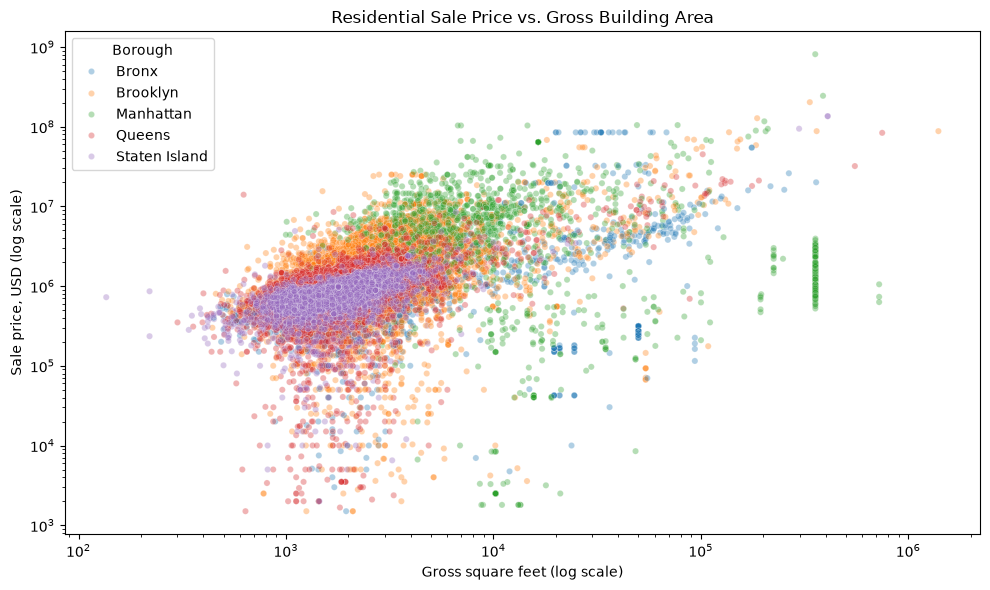

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=size_market_sales,
    x="gross_square_feet",
    y="sale_price",
    hue="borough",
    alpha=0.35,
    s=20,
    ax=ax,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set(
    title="Residential Sale Price vs. Gross Building Area",
    xlabel="Gross square feet (log scale)",
    ylabel="Sale price, USD (log scale)",
)

ax.legend(title="Borough")

fig.tight_layout()
plt.show()

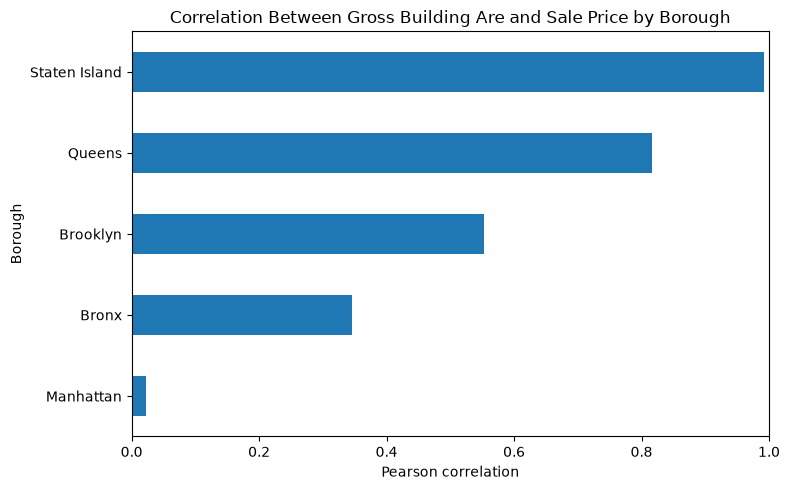

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))

borough_size_correlations.sort_values().plot(
    kind="barh",
    ax=ax,
)

ax.set(
    title="Correlation Between Gross Building Are and Sale Price by Borough",
    xlabel="Pearson correlation",
    ylabel="Borough",
)

ax.set_xlim(0, 1)

fig.tight_layout()
plt.show()

### Size-Price Findings

> **What relationship exists between property size and sale price?**
> 
> **Does the relationship between property size and sale price differ by borough?**

Across the final size-analysis population, gross building area and recorded sale price have a positive but relatively weak overall linear association (Pearson *r* = 0.221). The pooled relationship masks substantial geographic variation: correlations range from 0.993 in Staten Island and 0.816 in Queens to 0.023 in Manhattan.

The log-scaled scatterplot shows that larger properties generally sell for higher recorded prices, while substantial price variation remains among properties of similar size. The strength of this relationship is therefore not consistent across boroughs.

Manhattan requires particular caution because gross building area is available for only a small share of its residential positive-price and is largely unavailable for condo and co-op transactions. The near-zero Manhattan correlation therefore describes the limited size-eligible population rather than the borough's residential market as a whole. Correlations are descriptive associations and do not establish that differences in building size cause differences in sale price.

In [60]:
# Summarize price per square foot across boroughs in the final
# size-analysis population
borough_ppsf_summary = (
    size_market_sales
    .groupby("borough")["price_per_sqft"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .sort_values("50%", ascending=False)
)

borough_ppsf_summary.round(2)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
borough,,,,,,,,,,,
Manhattan,1573.0,961.12,1258.74,0.12,121.91,591.24,1228.02,2484.59,3426.46,5546.67,15322.70
Brooklyn,12750.0,644.76,471.33,0.25,393.84,555.56,775.07,1080.44,1382.64,2208.55,10333.33
Queens,16154.0,553.71,283.13,0.72,417.14,541.23,673.14,810.19,909.09,1147.70,22400.00
Staten Island,7542.0,465.63,185.42,1.38,366.93,452.87,549.22,652.17,732.79,940.46,5330.88
Bronx,4711.0,375.07,240.83,0.40,271.23,356.16,445.04,552.29,641.59,1065.96,4234.02


In [61]:
# Examine the overall PPSF distribution before choosing
# the visualization scale.
size_market_sales["price_per_sqft"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count    42730.00
mean       560.63
std        425.16
min          0.12
50%        500.64
75%        660.00
90%        866.56
95%       1068.14
99%       2011.41
max      22400.00
Name: price_per_sqft, dtype: float64

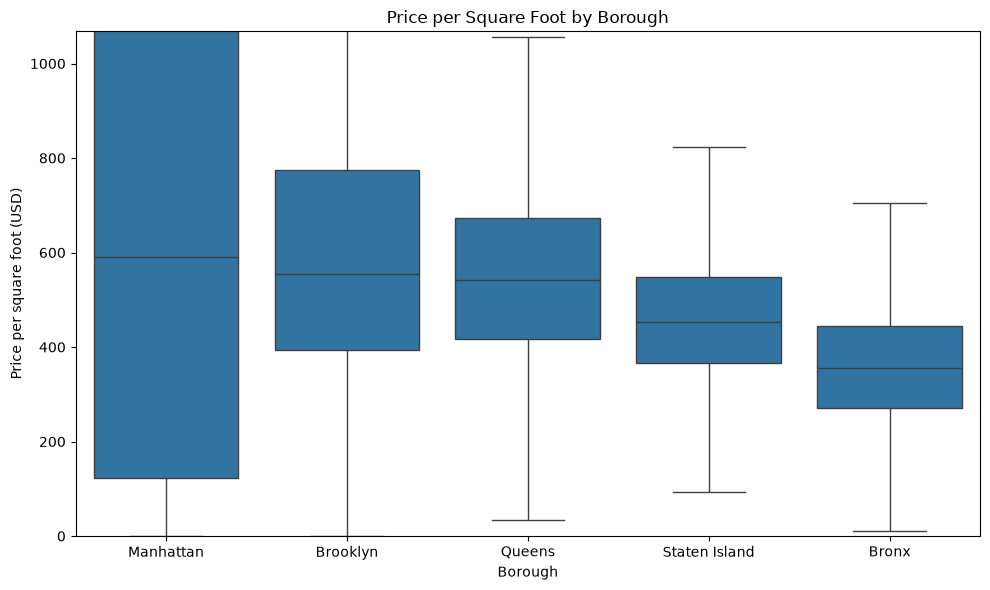

In [62]:
ppsf_display_limit = size_market_sales["price_per_sqft"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=size_market_sales,
    x="borough",
    y="price_per_sqft",
    order=[
        "Manhattan",
        "Brooklyn",
        "Queens",
        "Staten Island",
        "Bronx",
    ],
    showfliers=False,
    ax=ax,
)

ax.set_ylim(0, ppsf_display_limit)

ax.set(
    title="Price per Square Foot by Borough",
    xlabel="Borough",
    ylabel="Price per square foot (USD)",
)

fig.tight_layout()
plt.show()

In [63]:
# Assess neighborhood sample sizes before comparing
# neighborhood-level PPSF
neighborhood_sample_sizes = (
    size_market_sales
    .groupby(["borough", "neighborhood"])
    .size()
    .rename("sales")
)

neighborhood_sample_sizes.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).round(2)

count     244.00
mean      175.12
std       183.11
min         1.00
25%        48.75
50%       106.00
75%       257.00
90%       415.90
95%       561.65
max      1200.00
Name: sales, dtype: float64

In [64]:
# Compare neighborhood PPSF only where at least 50 eligible sales
# are available.
neighborhood_ppsf_summary = (
    size_market_sales
    .groupby(["borough", "neighborhood"])
    .agg(
        sales=("price_per_sqft", "size"),
        median_price_per_sqft=("price_per_sqft", "median"),
    )
    .query("sales >= 50")
    .sort_values("median_price_per_sqft", ascending=False)
)

neighborhood_ppsf_summary.head(20).round(2)

sales  median_price_per_sqft
borough   neighborhood                                         
Manhattan GREENWICH VILLAGE-WEST     104                2428.36
          UPPER EAST SIDE (59-79)    132                1594.90
Brooklyn  BROOKLYN HEIGHTS            74                1394.78
          COBBLE HILL                 70                1388.42
Manhattan UPPER EAST SIDE (79-96)     78                1223.37
Brooklyn  PARK SLOPE SOUTH           105                1161.84
          BOERUM HILL                100                1149.10
          CARROLL GARDENS            131                1107.14
          PARK SLOPE                 257                1102.04
Manhattan CHELSEA                     65                1100.94
Brooklyn  FORT GREENE                 99                1045.45
          WINDSOR TERRACE             97                1007.33
          GOWANUS                     88                 953.68
          CLINTON HILL               111                 903.95
          PROSPECT HEIGHTS            64                 885.92
Manhattan UPPER WEST SIDE (79-96)     81                 857.84
Brooklyn  OCEAN PARKWAY-NORTH        317                 856.73
Manhattan EAST VILLAGE                59                 805.04
Brooklyn  WILLIAMSBURG-EAST          153                 781.25
Queens    FOREST HILLS               266                 751.92

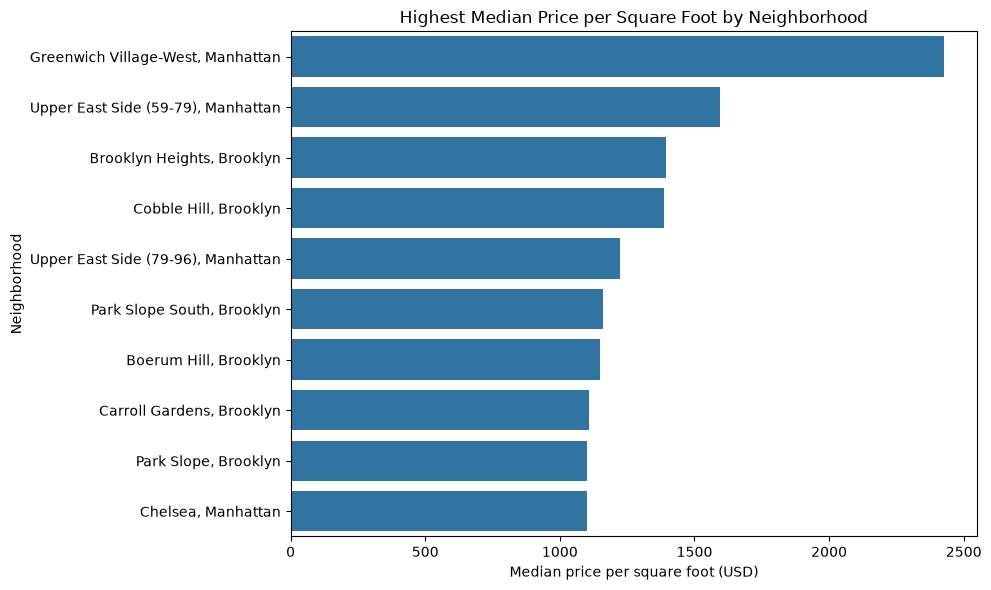

In [65]:
top_neighborhoods = (
    neighborhood_ppsf_summary
    .head(10)
    .reset_index()
)

top_neighborhoods["location"] = (
    top_neighborhoods["neighborhood"].str.title()
    + ", "
    + top_neighborhoods["borough"]
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_neighborhoods,
    x="median_price_per_sqft",
    y="location",
    ax=ax,
)

ax.set(
    title="Highest Median Price per Square Foot by Neighborhood",
    xlabel="Median price per square foot (USD)",
    ylabel="Neighborhood",
)

fig.tight_layout()
plt.show()

### Price-per-Square-Foot Findings

> **How does price per square foot vary across boroughs and neighborhoods?**

Median price per square foot varies geographically with the size-eligible residential sales population. Manhattan has the highest borough median at approximately `$591` per square foot, followed by Brooklyn (`$556`), Queens (`$541`), Staten Island (`$453`), and the Bronx (`$336`). Manhattan also shows substantially greater dispersion than the other boroughs.

Neighborhood-level differences are more pronounced. Among borough-neighborhood groups with at least 50 eligible sales, Greenwich Village-West has the highest median price per square foot at approximately `$2,428`, followed by Upper East Side (59-79) at `$1,595`. Several Brooklyn neighborhoods, including Brooklyn Heights, Cobble Hill, Park Slope South, Boerum Hill, Carroll Gardens, and Park Slope, also rank among the highest.

These comparisons apply only to transactions with usable gross building area and recorded sale prices above `$1,000`. Gross square footage is largely unavailable for condo and co-op transactions, particularly in Manhattan, so the results should not be interpreted as comprehensive rankings of the full NYC residential market.

## Property Characteristics Across Boroughs

To assess whether property-price patterns are consistent across locations, median recorded sale prices are compared across residential property categories and boroughs. This complements the borough-specific size correlations by examining whether category-level price patterns also vary geographically.

In [66]:
# Compare median sale prices for residential property categories
# across boroughs.
borough_category_prices = (
    residential_sales
    .groupby(["building_class_category", "borough"])
    .agg(
        sales=("sale_price", "size"),
        median_sale_price=("sale_price", "median"),
    )
    .reset_index()
)

borough_category_prices.pivot(
    index="building_class_category",
    columns="borough",
    values="median_sale_price",
).round(0)

borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
building_class_category,,,,,
01 ONE FAMILY DWELLINGS,635000.0,880500.0,6850000.0,789000.0,678000.0
02 TWO FAMILY DWELLINGS,785000.0,1125000.0,3662500.0,950000.0,850000.0
03 THREE FAMILY DWELLINGS,945000.0,1451250.0,2000000.0,1250000.0,880000.0
04 TAX CLASS 1 CONDOS,407000.0,800000.0,1800000.0,622500.0,480000.0
07 RENTALS - WALKUP APARTMENTS,1063334.0,1600000.0,3968924.0,1250000.0,1000000.0
08 RENTALS - ELEVATOR APARTMENTS,5500000.0,8500000.0,1887836.0,9003979.0,114646146.0
09 COOPS - WALKUP APARTMENTS,127500.0,690000.0,590000.0,315677.0,262450.0
10 COOPS - ELEVATOR APARTMENTS,270000.0,430000.0,850000.0,330000.0,250000.0
12 CONDOS - WALKUP APARTMENTS,405000.0,750000.0,805000.0,595000.0,305000.0


In [67]:
# Check brough-category sample sizes
borough_category_prices.pivot(
    index="building_class_category",
    columns="borough",
    values="sales",
).fillna(0).astype(int)

borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
building_class_category,,,,,
01 ONE FAMILY DWELLINGS,1697,3880,219,9800,5590
02 TWO FAMILY DWELLINGS,1942,5768,166,5549,2154
03 THREE FAMILY DWELLINGS,803,2006,73,1149,71
04 TAX CLASS 1 CONDOS,157,772,13,442,640
07 RENTALS - WALKUP APARTMENTS,458,1429,716,507,55
08 RENTALS - ELEVATOR APARTMENTS,107,120,351,63,4
09 COOPS - WALKUP APARTMENTS,124,839,1304,1786,108
10 COOPS - ELEVATOR APARTMENTS,1745,3258,10671,5627,107
12 CONDOS - WALKUP APARTMENTS,23,582,180,461,66


In [68]:
# Retain borough-category comparisons supported by at
# least 50 recorded sales.
borough_category_reliable = (
    borough_category_prices
    .loc[borough_category_prices["sales"] >= 50]
    .copy()
)

borough_category_reliable.pivot(
    index="building_class_category",
    columns="borough",
    values="median_sale_price",
).round(0)

borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
building_class_category,,,,,
01 ONE FAMILY DWELLINGS,635000.0,880500.0,6850000.0,789000.0,678000.0
02 TWO FAMILY DWELLINGS,785000.0,1125000.0,3662500.0,950000.0,850000.0
03 THREE FAMILY DWELLINGS,945000.0,1451250.0,2000000.0,1250000.0,880000.0
04 TAX CLASS 1 CONDOS,407000.0,800000.0,NaN,622500.0,480000.0
07 RENTALS - WALKUP APARTMENTS,1063334.0,1600000.0,3968924.0,1250000.0,1000000.0
08 RENTALS - ELEVATOR APARTMENTS,5500000.0,8500000.0,1887836.0,9003979.0,NaN
09 COOPS - WALKUP APARTMENTS,127500.0,690000.0,590000.0,315677.0,262450.0
10 COOPS - ELEVATOR APARTMENTS,270000.0,430000.0,850000.0,330000.0,250000.0
12 CONDOS - WALKUP APARTMENTS,NaN,750000.0,805000.0,595000.0,305000.0


### Cross-Borough Findings

Property-category price patterns vary substantially across boroughs. Among borough-category combinations with at least 50 recorded sales, median prices for one-, two-, and three-family dwellings differ considerably by location, with Manhattan generally showing the highest medians. Similar geographic differences are present across condo and co-op categories.

These results reinforce the borough-specific size correlations: relationships between residential property characteristics and recorded sale price are not uniform across New York City. Location and property type provide complementary information, and citywide summaries can conceal substantial differences between boroughs.

The 50-sale minimum is used only to avoid emphasizing sparsely represented borough-category combinations; it does not remove those transactions from the underlying residential sales population. Category comparisons remain descriptive because the mix of properties sold within each category can differ across boroughs.

## Conclusion

Recorded residential sale prices across New York City in 2024–2025 varied substantially by location, property size, and property category.

Manhattan had the highest borough median sale price at approximately `$1.20 million`, followed by Brooklyn at `$985,000`. Queens and Staten Island had similar medians of approximately `$690,000` and `$680,000`, while the Bronx had the lowest median at `$625,000`. Sale-price distributions were strongly right-skewed, with a relatively small number of high-value transactions extending the upper tails.

Observed residential positive-price sales increased from 47,443 in 2024 to 50,406 in 2025, a 6.25% increase. The overall median recorded sale price increased from `$799,000` to `$840,500`, or 5.19%, and both transaction counts and median prices were higher in 2025 within each borough. These are descriptive year-to-year differences and may partly reflect changes in the composition of properties sold.

Property category was also associated with substantial differences in recorded prices. Rental apartment buildings generally had higher median transaction values than individual houses, condos, and co-ops, although these categories represent different types of transaction units and should not be interpreted as directly equivalent properties.

Within the market-oriented size-analysis subset, gross building area had a positive but relatively weak overall association with recorded sale price (Pearson *r* = 0.221). The relationship varied substantially by borough, from 0.993 in Staten Island and 0.816 in Queens to 0.023 in Manhattan, demonstrating that the size-price relationship is not consistent across the city.

Price per square foot also varied geographically. Borough medians ranged from approximately `$591` in Manhattan and `$556` in Brooklyn to `$356` in the Bronx. Among neighborhoods with at least 50 eligible sales, Greenwich Village-West had the highest median at approximately `$2,428` per square foot. These size-based comparisons apply only to transactions with usable gross building area and therefore do not represent the full residential market.

Overall, the analysis shows that citywide price summaries conceal substantial variation across boroughs and property categories. Location, property type, and building size are all associated with recorded residential transaction values, but the strength and form of these relationships differ across New York City.

## Limitations

Several limitations should be considered when interpreting this analysis:

- **Recorded sale price is not necessarily market value.** A positive sale price does not confirm that a transaction was an arm's-length market sale. Nominal and other non-standard transactions may remain in analyses based on the broader residential positive-price population.

- **Building-area coverage is incomplete.** Gross square footage is largely unavailable for condo and co-op transactions and is particularly limited in Manhattan. Size and price-per-square-foot findings therefore describe a narrower subset of residential properties rather than the full NYC residential market.

- **Nominal-price transactions affect size-based metrics.** For analyses relating building area to transaction value, recorded sale prices of $1,000 or less were excluded after the data showed a distinct concentration of nominal values. This threshold improves the usefulness of size and price-per-square-foot comparisons but does not establish that the remaining transactions are verified market sales.

- **Extreme values were generally retained.** Large properties, high sale prices, and high price-per-square-foot observations were not removed solely because they were extreme. Some may represent legitimate high-value transactions, while others may reflect package transactions or source-data conventions that cannot be resolved from the available fields.

- **Year-to-year comparisons are observational.** Differences between 2024 and 2025 may reflect changes in the number, location, and types of properties sold as well as changes in transaction values. The analysis does not estimate market appreciation for identical properties.

- **The analysis is descriptive, not causal.** Associations between location, building size, property category, and recorded sale price do not establish that these characteristics cause the observed differences in transaction values.